In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def simulate_ddm(v, a=1.0, sigma=1.0, z=0.5, dt=0.001, max_t=5):
    x = z * a
    t = 0

    while t < max_t:
        dx = v * dt + sigma * np.sqrt(dt) * np.random.randn()
        x += dx
        t += dt

        #Upper and lower boundaries
        if x >= a:
            return t, 1   
        elif x <= 0:
            return t, 0   

    return None, None  

In [4]:

drift_values = np.linspace(0.5, 1.5, 25)

upper_means = []
lower_means = []

for v in drift_values:
    upper_rts = []
    lower_rts = []

    for _ in range(2000):
        rt, choice = simulate_ddm(v)

        if rt is not None:
            if choice == 1:
                upper_rts.append(rt)
            else:
                lower_rts.append(rt)

    upper_means.append(np.mean(upper_rts))
    lower_means.append(np.mean(lower_rts))

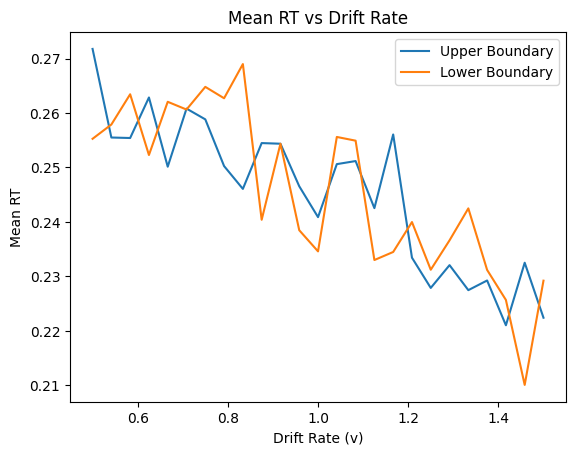

In [5]:
plt.figure()
plt.plot(drift_values, upper_means, label="Upper Boundary")
plt.plot(drift_values, lower_means, label="Lower Boundary")
plt.xlabel("Drift Rate (v)")
plt.ylabel("Mean RT")
plt.title("Mean RT vs Drift Rate")
plt.legend()
plt.show()

#Questions: What do you observe regarding the mean difference? Describe and interpret your results.

- As drift rate increases, both the upper boundary and the lower boundary show a general decrease in mean response times. 
  Although the graph shows that there are points where it spikes upwards aftrer a decrease, the line of best fit trends downwards.
- This decrease in mean RT indicates that the model is becoming faster in decision making.

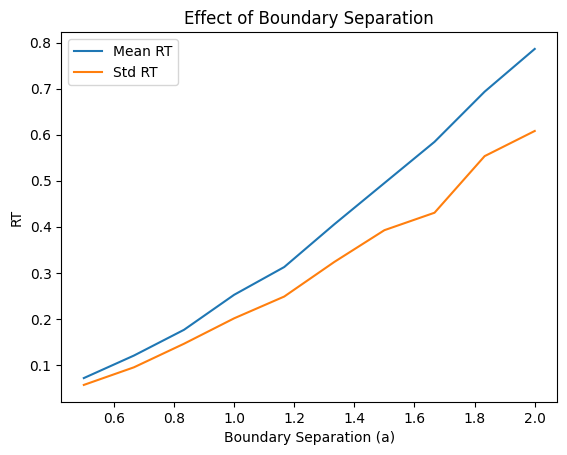

In [14]:
#Varying boundary separation
a_values = np.linspace(0.5, 2.0, 10)

means = []
stds = []

for a in a_values:
    rts = []

    for _ in range(2000):
        rt, _ = simulate_ddm(v=1.0, a=a)
        if rt is not None:
            rts.append(rt)

    means.append(np.mean(rts))
    stds.append(np.std(rts))

plt.figure()
plt.plot(a_values, means, label="Mean RT")
plt.plot(a_values, stds, label="Std RT")
plt.xlabel("Boundary Separation (a)")
plt.ylabel("RT")
plt.title("Effect of Boundary Separation")
plt.legend()
plt.show()

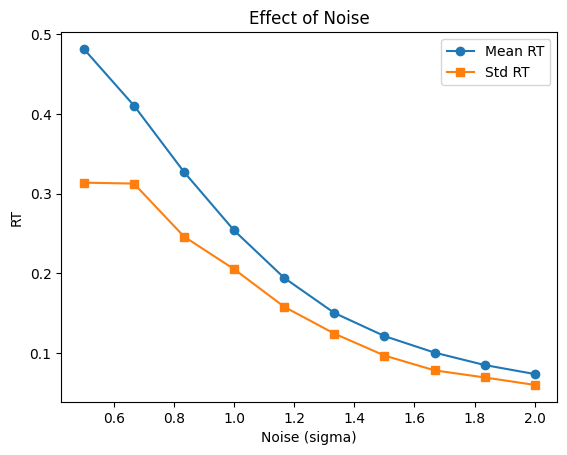

In [15]:
#Varying Noise
sigma_values = np.linspace(0.5, 2.0, 10)

means = []
stds = []

for sigma in sigma_values:
    rts = []

    for _ in range(2000):
        z, a = 0.5, 1.0
        x = z * a 
        t = 0
        dt = 0.001

        while t < 5:
            dx = 1.0 * dt + sigma * np.sqrt(dt) * np.random.randn()
            x += dx
            t += dt

            if x >= 1.0 or x <= 0:
                rts.append(t)
                break

    means.append(np.mean(rts))
    stds.append(np.std(rts))

plt.figure()
plt.plot(sigma_values, means, marker='o', label="Mean RT")
plt.plot(sigma_values, stds, marker='s', label="Std RT")
plt.xlabel("Noise (sigma)")
plt.ylabel("RT")
plt.title("Effect of Noise")
plt.legend()
plt.show()

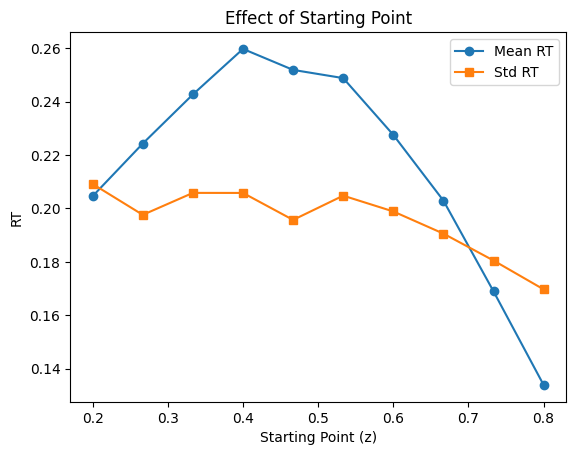

In [ ]:
#Varying starting point
z_values = np.linspace(0.2, 0.8, 10)

means = []
stds = []

for z in z_values:
    rts = []

    for _ in range(2000):
        x = z * 1.0   # z * a
        t = 0
        dt = 0.001

        while t < 5:
            dx = 1.0 * dt + 1.0 * np.sqrt(dt) * np.random.randn()
            x += dx
            t += dt

            if x >= 1.0 or x <= 0:
                rts.append(t)
                break

    means.append(np.mean(rts))
    stds.append(np.std(rts))

plt.figure()
plt.plot(z_values, means, marker='o', label="Mean RT")
plt.plot(z_values, stds, marker='s', label="Std RT")
plt.xlabel("Starting Point (z)")
plt.ylabel("RT")
plt.title("Effect of Starting Point")
plt.legend()
plt.show()

After plotting the three graphs where only one variable is separated to vary, here are some of my observations.

- When increasing boundary separation, both the mean and the standard deviation of response times increase as well. This is because the model takes longer to reach a larger boundary while using more time to accumulate evidence.
- When increasing noise, both the mean response time and the standard deviation of response times decrease. This is probably due to the increase in noise causing a larger fluctuation in the accumulation of evidence, which also increases 
  the chance to reach a boundary.
- When increasing the starting point, the mean rt first increases, then decreases once z reaches past 0.4. The decrease is because there is now a shorter distance to boundary.